# Model results for all cantons

## Initial configuration

In [1]:
import pandas as pd
import sys
import numpy as np

sys.path.append('../../models')

from model_rr import Model

In [2]:
df = pd.read_csv('../../data/clean/full_data.csv')

In [3]:
cantons = [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 201, -202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 301, 302, 303, 304, 305, 306, 307, 308, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 701, 702, 703, 704, 705, 706]

cantons = [str(x) for x in cantons]

# Preparing the data

In [4]:
instancia = Model(df, "full")
X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = instancia.partition()

# Random Forest

## Fitting the model

In [5]:
instancia.rf_reg(X_combined, y_combined, X_test, y_test, test, pds, epsilon)

RF Model Ready for full


## Calculate NRMSE

In [6]:
cod_cant_rf, nrmse_rf = instancia.calculate_nrmse("rf", epsilon)
round(nrmse_rf, 4)

np.float64(1.6705)

In [ ]:
instancia.confint_nrmse("rf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

### Feature importance

              Feature    imp_rf    std_rf
0            rr_lag_1  0.213181  0.010962
1            rr_lag_2  0.117788  0.009123
2            rr_lag_4  0.027804  0.005567
3            rr_lag_3  0.021627  0.004636
4    precip_max_lag_3  0.001094  0.000568
..                ...       ...       ...
103   tmax_mean_lag_4 -0.002329  0.000539
104   tmax_mean_lag_1 -0.002760  0.000660
105   temp_prom_lag_1 -0.002804  0.000546
106   tmin_mean_lag_4 -0.003458  0.000739
107   temp_prom_lag_3 -0.005056  0.000628

[108 rows x 3 columns]


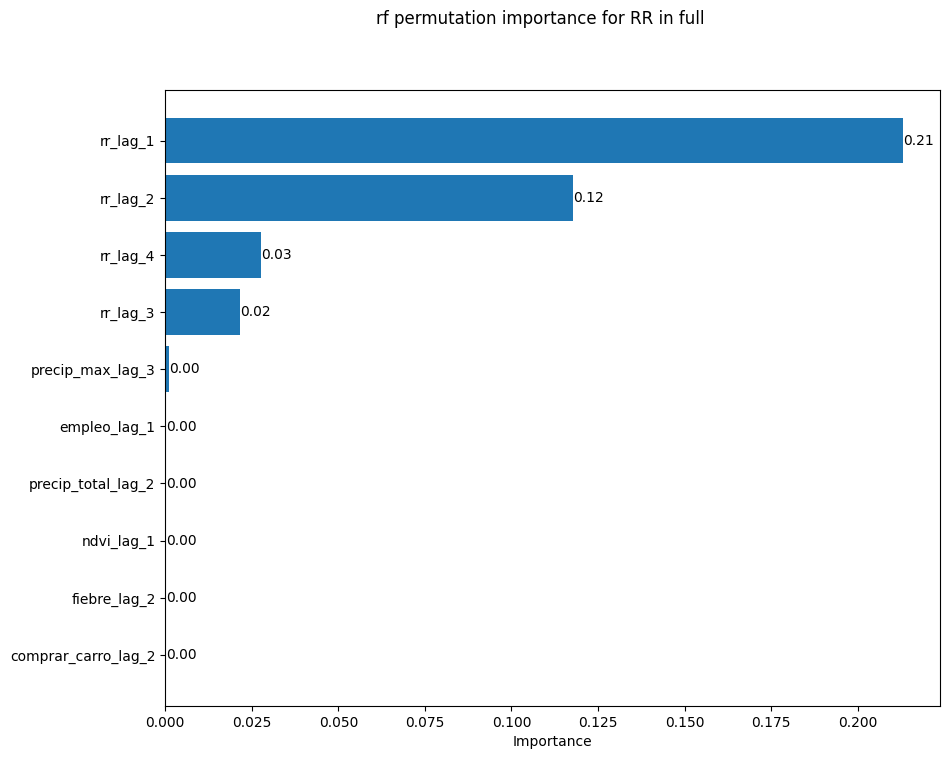

,Feature,imp_rf,std_rf
0,rr_lag_1,0.213181,0.010962
1,rr_lag_2,0.117788,0.009123
2,rr_lag_4,0.027804,0.005567
3,rr_lag_3,0.021627,0.004636
4,precip_max_lag_3,0.001094,0.000568
...,...,...,...
103,tmax_mean_lag_4,-0.002329,0.000539
104,tmax_mean_lag_1,-0.002760,0.000660
105,temp_prom_lag_1,-0.002804,0.000546
106,tmin_mean_lag_4,-0.003458,0.000739


In [7]:
instancia.var_importance(X_test, y_test, "rf", repeats = 100, var = "RR")

### Feature selection

Optimal number of features for RR and rf: 6
Selected features: ['rr_lag_4', 'rr_lag_3', 'rr_lag_2', 'rr_lag_1', 'tmin_mean_lag_4', 'nino34ssta_lag_4']


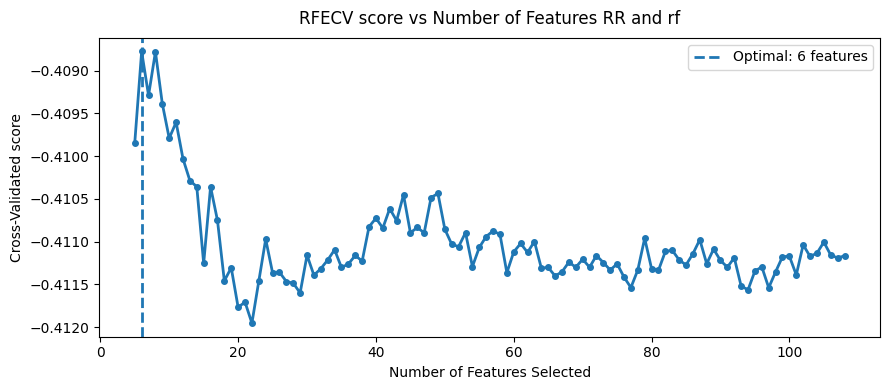

New NRMSE with selected features: -1.7018


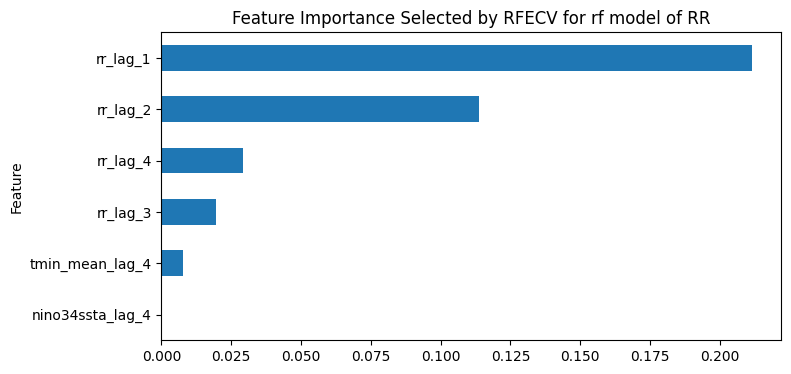

In [8]:
instancia.rfecv_selection("rf", X_combined, y_combined, X_test, y_test, pds, epsilon, repeats = 100, var = "RR")

# XGB

## Fit model

In [9]:
instancia.xgb_reg(X_combined, y_combined, X_test, y_test, test, pds, epsilon)

XGB Model Ready for full


## Calculate NRMSE

In [10]:
cod_cant_xgb, nrmse_xgb = instancia.calculate_nrmse("xgb", epsilon)

nrmse_xgb 

np.float64(1.6615869468430067)

In [11]:
instancia.confint_nrmse("xgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 1.67
lower bound: 1.65, upper bound: 1.69


### Feature importance

                 Feature   imp_xgb   std_xgb
0               rr_lag_1  0.228715  0.011006
1               rr_lag_2  0.086396  0.007653
2               rr_lag_4  0.030009  0.004987
3               rr_lag_3  0.026500  0.004629
4     precip_total_lag_2  0.000645  0.000365
..                   ...       ...       ...
103     precip_max_lag_4 -0.000225  0.000175
104      temp_prom_lag_1 -0.000228  0.000125
105      tmin_mean_lag_1 -0.000259  0.000189
106  precip_median_lag_3 -0.000265  0.000173
107      tmax_mean_lag_3 -0.000575  0.000578

[108 rows x 3 columns]


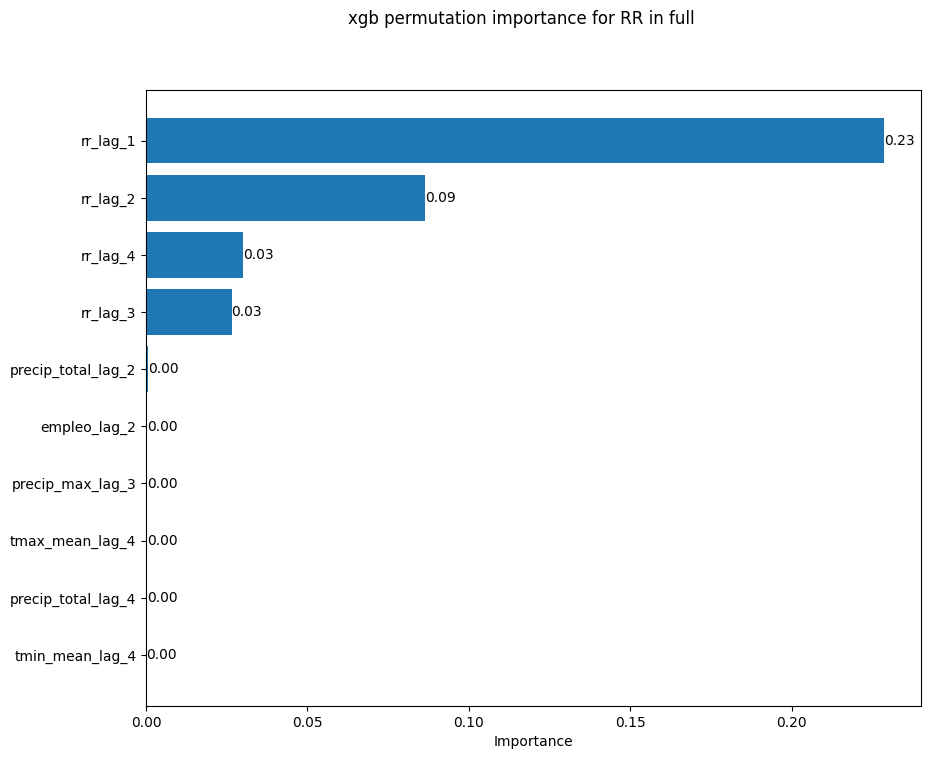

,Feature,imp_xgb,std_xgb
0,rr_lag_1,0.228715,0.011006
1,rr_lag_2,0.086396,0.007653
2,rr_lag_4,0.030009,0.004987
3,rr_lag_3,0.026500,0.004629
4,precip_total_lag_2,0.000645,0.000365
...,...,...,...
103,precip_max_lag_4,-0.000225,0.000175
104,temp_prom_lag_1,-0.000228,0.000125
105,tmin_mean_lag_1,-0.000259,0.000189
106,precip_median_lag_3,-0.000265,0.000173


In [12]:
instancia.var_importance(X_test, y_test, "xgb", repeats = 100, var = "RR")

### Feature selection

Optimal number of features for RR and xgb: 48
Selected features: ['nino34ssta', 'rr_lag_4', 'rr_lag_3', 'rr_lag_2', 'rr_lag_1', 'ndvi_lag_4', 'ndvi_lag_3', 'ndvi_lag_2', 'ndvi_lag_1', 'tmax_mean_lag_4', 'tmax_mean_lag_3', 'tmax_mean_lag_2', 'tmax_mean_lag_1', 'tmin_mean_lag_4', 'tmin_mean_lag_3', 'tmin_mean_lag_2', 'tmin_mean_lag_1', 'nino34ssta_lag_4', 'nino34ssta_lag_3', 'nino34ssta_lag_2', 'temp_prom_lag_4', 'temp_prom_lag_3', 'temp_prom_lag_2', 'fiebre_lag_1', 'desempleo_lag_2', 'empleo_lag_4', 'empleo_lag_3', 'empleo_lag_2', 'empleo_lag_1', 'tiquetes_avion_lag_4', 'vacaciones_lag_4', 'vacaciones_lag_2', 'vacaciones_lag_1', 'corte_agua_lag_3', 'corte_de_agua_lag_3', 'corte_de_agua_lag_2', 'corte_de_agua_lag_1', 'dengue_lag_4', 'dengue_lag_1', 'precip_total_lag_4', 'precip_total_lag_3', 'precip_total_lag_2', 'precip_max_lag_4', 'precip_max_lag_3', 'precip_max_lag_2', 'precip_max_lag_1', 'precip_median_lag_3', 'precip_median_lag_1']


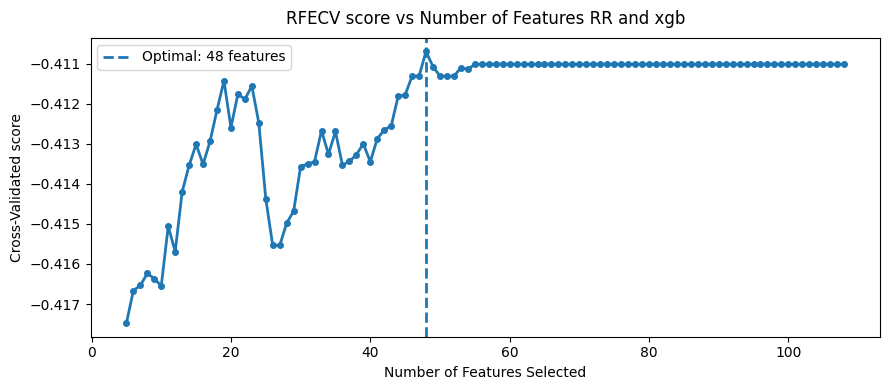

New NRMSE with selected features: -1.6856


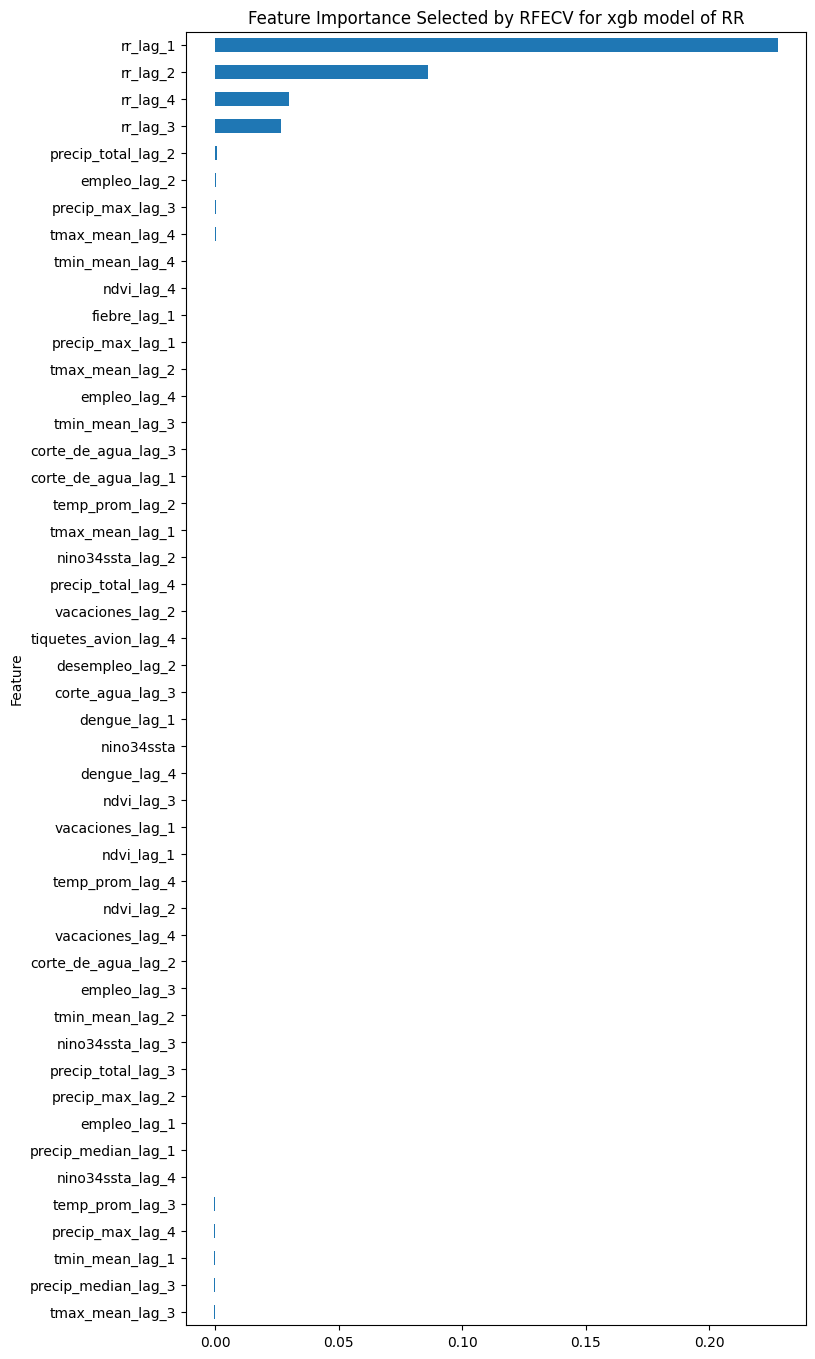

In [13]:
instancia.rfecv_selection("xgb", X_combined, y_combined, X_test, y_test, pds, epsilon, repeats = 100, var = "RR")

# HRF

## Fit models

In [ ]:
instancia.hybrid("hrf", X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon)

## Calculate NRMSE

In [ ]:
cod_cant_hrf, nrmse_hrf = instancia.calculate_nrmse("hrf", epsilon)

nrmse_hrf 

In [ ]:
instancia.confint_nrmse("hrf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

### Feature importance

In [ ]:
instancia.var_importance(X_test, y_test, "hrf", repeats = 100, var = "RR")

### Feature selection

In [ ]:
instancia.rfecv_selection("hrf", X_combined, y_combined, X_test, y_test, pds, epsilon, repeats = 100, var = "RR")

# HXGB

## Fit model

In [ ]:
instancia.hybrid("hxgb", X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon)

## Calculate NRMSE

In [ ]:
cod_cant_hxgb, nrmse_hxgb = instancia.calculate_nrmse("hxgb", epsilon)

nrmse_hxgb 

In [ ]:
instancia.confint_nrmse("hxgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

### Feature importance

In [ ]:
instancia.var_importance(X_test, y_test, "hxgb", repeats = 100, var = "RR")

### Feature selection

In [ ]:
instancia.rfecv_selection("hxgb", X_combined, y_combined, X_test, y_test, pds, epsilonrepeats = 100, var = "RR")